In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ======================= LOAD DATA ===========================
data = pd.read_csv("/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv", low_memory=False)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CNN RESHAPE ===========================
X_train_sel = X_train_sel.reshape(X_train_sel.shape[0], X_train_sel.shape[1], 1)
X_test_sel  = X_test_sel.reshape(X_test_sel.shape[0], X_test_sel.shape[1], 1)

# ======================= CLASS WEIGHTS ===========================
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ======================= MODEL ===========================
model = Sequential([
    Input(shape=(X_train_sel.shape[1], 1)),

    Conv1D(32, 3, activation='relu'),
    MaxPooling1D(2),

    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')
])

model.compile(optimizer=Adam(0.0003), loss='categorical_crossentropy', metrics=['accuracy'])

# ======================= TRAIN ===========================
y_train_cat = to_categorical(y_train, 5)

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model.fit(
    X_train_sel, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ======================= RESULTS ===========================
train_pred = np.argmax(model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(model.predict(X_test_sel), axis=1)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.8766 - loss: 0.3652 - val_accuracy: 0.9183 - val_loss: 0.2457
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9268 - loss: 0.1955 - val_accuracy: 0.9283 - val_loss: 0.2115
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9355 - loss: 0.1667 - val_accuracy: 0.9447 - val_loss: 0.1741
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9425 - loss: 0.1471 - val_accuracy: 0.9438 - val_loss: 0.1609
Epoch 5/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9496 - loss: 0.1287 - val_accuracy: 0.9459 - val_loss: 0.1596
Epoch 6/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9519 - loss: 0.1212 - val_accuracy: 0.9586 - val_loss: 0.1280
Epoch 7/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9553 - loss: 0.1170 - val_accuracy: 0.9652 - val_loss: 0.1197
Epoch 8/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9570 - loss: 0.1091 - 


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

🌐 Round 1/20
 Client 1 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 2 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 3 training...


...

 Client 4 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 5 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 20 Accuracy: 0.9694
3713/3713 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

🔥 FINAL CNN FL RESULTS 🔥
Training Accuracy : 0.969
Testing Accuracy  : 0.9694
Precision         : 0.983
F1 Score          : 0.9741

Confusion Matrix:
 [[14577    23    92   344   375]
 [   10 10656     9     0     2]
 [   14     1  2793     1     7]
 [   10     0     1   617    17]
 [    2     0     0     1   152]]


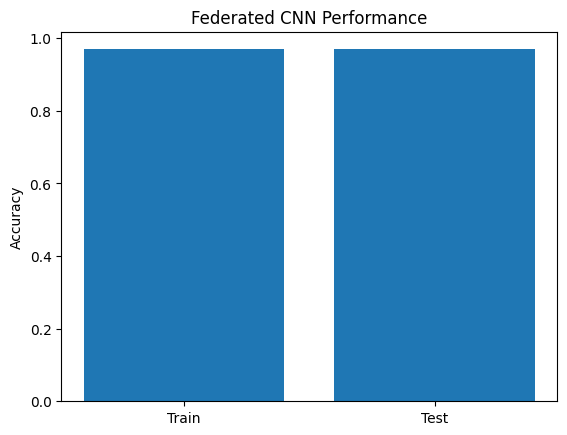

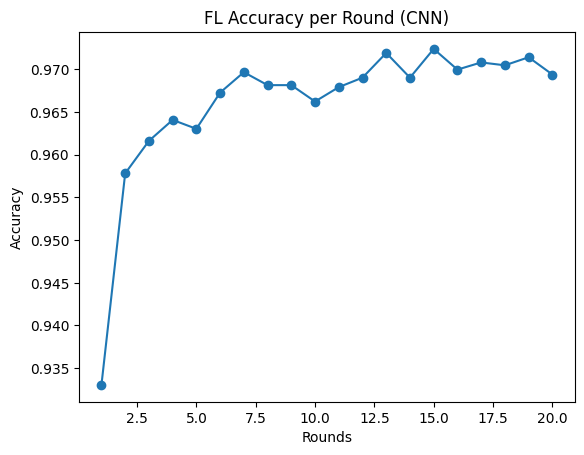


✅ CNN FEDERATED LEARNING COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv("/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv", low_memory=False)
print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CNN RESHAPE ===========================
X_train_sel = X_train_sel.reshape(X_train_sel.shape[0], X_train_sel.shape[1], 1)
X_test_sel  = X_test_sel.reshape(X_test_sel.shape[0], X_test_sel.shape[1], 1)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5

client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= CNN MODEL ===========================
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim, 1)),

        Conv1D(32, 3, activation='relu'),
        MaxPooling1D(2),

        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= WEIGHTED FEDAVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

for r in range(ROUNDS):
    print(f"\n🌐 Round {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights,
            callbacks=[early_stop]
        )

        local_weights.append(local_model.get_weights())

    # ================= FEDAVG =================
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # ================= EVALUATION =================
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\n🔥 FINAL CNN FL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated CNN Performance")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FL Accuracy per Round (CNN)")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\n✅ CNN FEDERATED LEARNING COMPLETE")